# Pauli Propagation

In [63]:
import math
from functools import partial
import numpy as np
from matplotlib import pyplot as plt

from qiskit.quantum_info import Statevector, Operator
from quantum_simulation_recipe.plot_config import *
from quantum_simulation_recipe.trotter import pf
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d

from resource_estimation import *

fig_dir, data_dir = './figs', './data'
plt.rcParams['font.family'] = 'sans-serif'
set_fontsize(linewidth=2.0)

## Pauli rotation 

Let $R_G(\theta)[P]:=e^{iG\theta/2} P e^{-iG\theta/2}$,
then 
$$R_G(\theta)[P]=P, \; [P,G]=0$$
$$R_G(\theta)[P]=\cos(\theta)P+\sin(\theta)P', \; P'=i[P,G]/2$$

In [36]:
XX = SparsePauliOp(['XX'],coeffs=[1.+0.j])
ZI = SparsePauliOp(['ZI'],coeffs=[1.+0.j])
ZZ = SparsePauliOp(['ZZ'],coeffs=[1.+0.j])
from quantum_simulation_recipe.trotter import expH 

print('XX:\n', XX.to_matrix())
print('ZI:\n', ZI.to_matrix())

theta = math.pi/8
print('theta:', theta)  
expXX = expH(XX, theta)
print('expXX:\n', expXX)
## set small number to zero by numpy setting
print('expXX[ZI]:\n', expXX @ ZI.to_matrix() @ expXX.conj().T)

analytic_expression = math.cos(theta*2)*XX + math.sin(theta*2)*commutator(XX, ZI)/2
print('Pauli rotation:', analytic_expression.simplify())

XX:
 [[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]]
ZI:
 [[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]
theta: 0.39269908169872414
expXX:
 [[0.92388+0.j       0.     +0.j       0.     +0.j       0.     -0.382683j]
 [0.     +0.j       0.92388+0.j       0.     -0.382683j 0.     +0.j      ]
 [0.     +0.j       0.     -0.382683j 0.92388+0.j       0.     +0.j      ]
 [0.     -0.382683j 0.     +0.j       0.     +0.j       0.92388+0.j      ]]
expXX[ZI]:
 [[ 0.707107+0.j        0.      +0.j        0.      +0.j
   0.      +0.707107j]
 [ 0.      +0.j        0.707107+0.j        0.      +0.707107j
   0.      +0.j      ]
 [ 0.      +0.j        0.      -0.707107j -0.707107+0.j
   0.      +0.j      ]
 [ 0.      -0.707107j  0.      +0.j        0.      +0.j
  -0.707107+0.j      ]]
Pauli rotation: SparsePauliOp(['XX', 'YX'],
         

## Exact VS Trotter VS Pauli surrogate

In [41]:
import numpy as np

def expect_value(ob, state):
    # if isinstance(state, Statevector):
    #     return np.abs(state.conj().T @ ob @ state)
    # elif isinstance(state, DensityMatrix):
    #     return np.trace(ob @ state)
    # else:
    #     raise ValueError('invalid state type')
    expval = state.conj().T @ ob @ state
    if expval.imag > 1e-7:
        print('imaginary part of expectation value is', expval.imag)
        raise ValueError('Expectation value is not real')
    return expval.real
    # return np.abs(state.conj().T @ ob @ state)


QIMF model with hx=0.8, hy=0.9, Jx=1, n=10
initial state:  0000000000
++++++++++++++++++++++++++++++++++++++++++++++++++

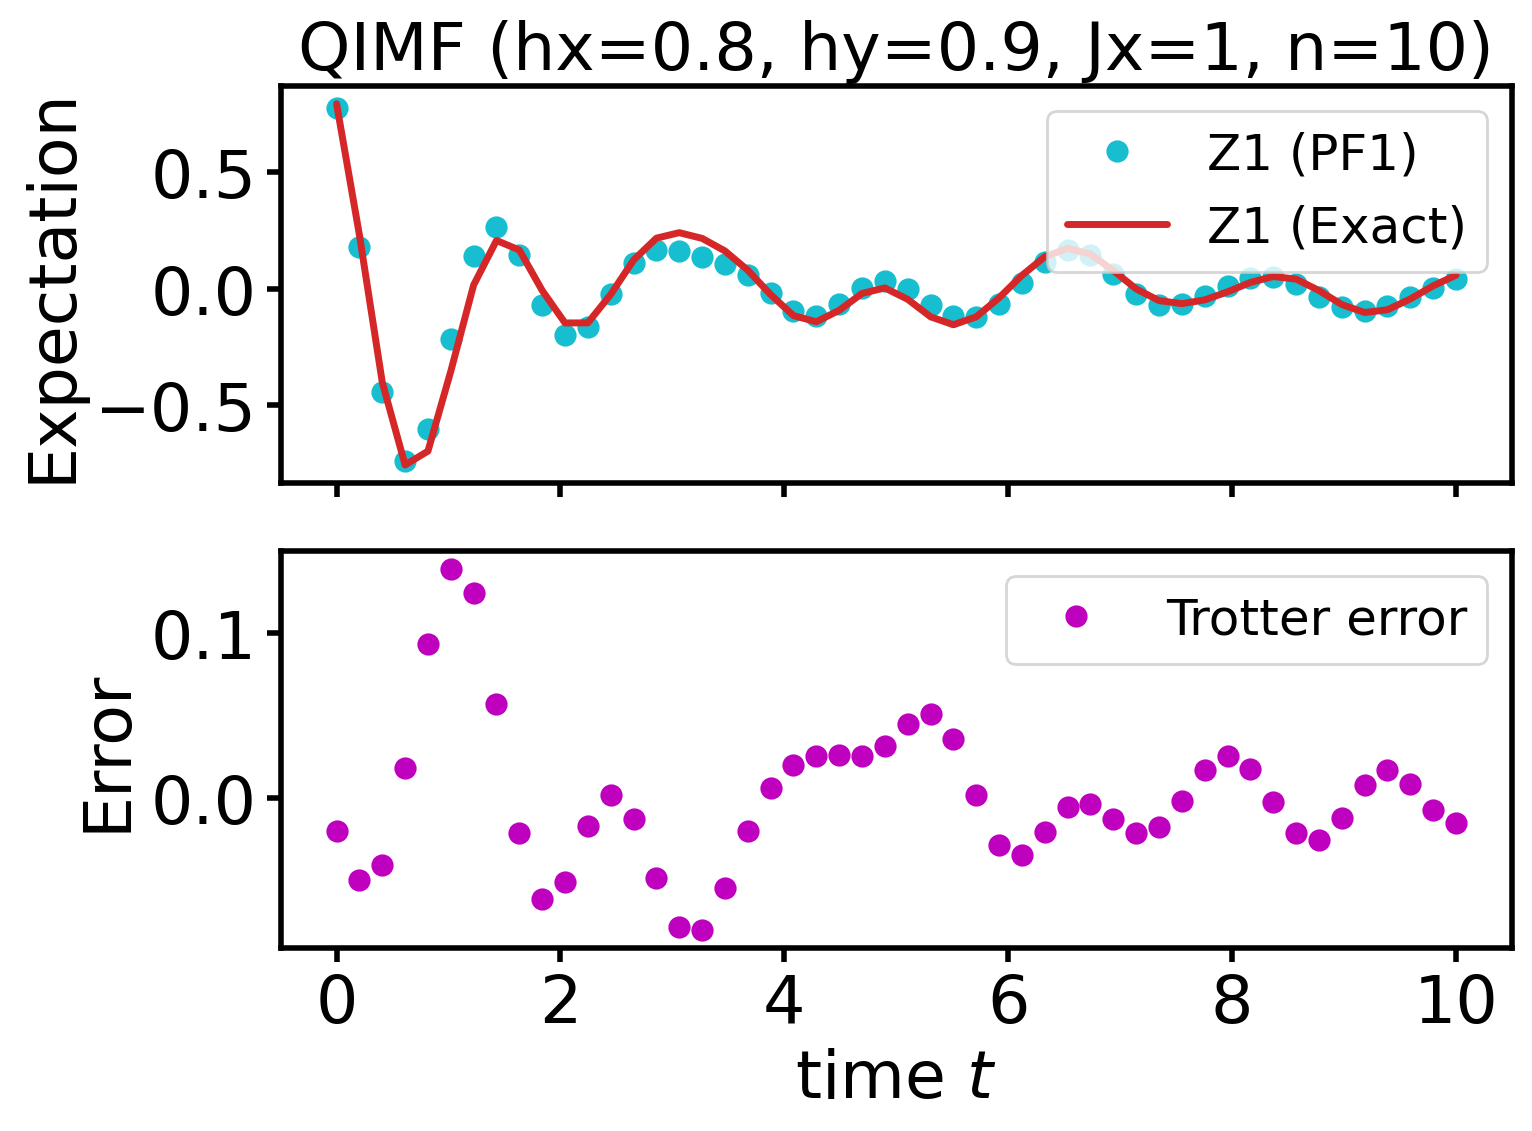

In [94]:
## QIMF model
n = 10
# n = 8
t_num = 50
# t_num = 100
t = n
t_list = np.linspace(0, t, t_num)

# hx, hy, Jx = 0.8090, 0.0, 1
hx, hy, Jx = 0.8, 0.9, 1
# hx, hy, Jx = 0.8090, 0.9045, 1
print(f'QIMF model with hx={hx}, hy={hy}, Jx={Jx}, n={n}')
qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
H_list = qimf.ham_par

r = t_num
U_dt_ideal = expH(sum(H_list), t/r, use_jax=False)
U_dt_appro = pf(H_list, t/r, 1, 1)

zzz = SparsePauliOp('Z'*n, 1).to_matrix()
xxx = SparsePauliOp('X'*n, 1).to_matrix()
zii = SparsePauliOp('I'*(n-1)+'Z', 1).to_matrix()
ziz = SparsePauliOp('Z'+'I'*(n-2)+'Z', 1).to_matrix()
mag = SparsePauliOp.from_sparse_list([('Z', [i], 1/n) for i in range(0, n)], n).to_matrix()
cor = SparsePauliOp.from_sparse_list([('ZZ', [i,i+1], 1/(n-1)) for i in range(0, n-1)], n).to_matrix()

init_state_str = '0'*n
# init_state_str = '+'*n
# init_state_str = '10'*(n//2)
print('initial state: ', init_state_str)
init_state = Statevector.from_label(init_state_str).data
ideal_current_state = init_state.data
appro_current_state = init_state.data
expval_dict = {'zzz': [], 'zii': [], 'ziz': [], 'xxx': [], 'mag': [], 'cor': [], 'pf1': []}
for _ in range(r):
    print('+', end='')
    ideal_current_state = U_dt_ideal @ ideal_current_state
    appro_current_state = U_dt_appro @ appro_current_state
    # expval_dict['xxx'].append(expect_value(xxx, ideal_current_state))
    # expval_dict['zzz'].append(expect_value(zzz, ideal_current_state))
    expval_dict['zii'].append(expect_value(zii, ideal_current_state))
    expval_dict['pf1'].append(expect_value(zii, appro_current_state))
    # expval_dict['ziz'].append(expect_value(ziz, ideal_current_state))
    # expval_dict['mag'].append(expect_value(mag, ideal_current_state))
    # expval_dict['cor'].append(expect_value(cor, ideal_current_state))

fig, axes = plt.subplots(2, 1, sharex=True)
# ax.plot(t_list, expval_dict['xxx'], '-', label='xxx')
# ax.plot(t_list, expval_dict['zzz'], '-', label='zzz')
axes[0].plot(t_list, expval_dict['pf1'], '.', label='Z1 (PF1)', color='tab:cyan')
axes[0].plot(t_list, expval_dict['zii'], '-', label='Z1 (Exact)', color='tab:red')
# ax.plot(t_list, expval_dict['ziz'], '-', label='ziz')
# ax.plot(t_list, expval_dict['mag'], '-', label='mag') 
# ax.plot(t_list, expval_dict['cor'], '-', label='cor')
axes[0].set_ylabel('Expectation')
axes[1].plot(t_list, np.subtract(expval_dict['pf1'],expval_dict['zii']), '.', label='Trotter error', color='m')
axes[1].set_xlabel(rf'time $t$')
axes[1].set_ylabel('Error')
# axes[1].set_yscale('log')
axes[0].set_title(fr'QIMF (hx={hx}, hy={hy}, Jx={Jx}, n={n})')
axes[0].legend(loc='upper right'); axes[1].legend(loc='upper right')
fig.savefig(f'{fig_dir}/qimf_n={n}.pdf', bbox_inches='tight')

### Pauli string weight/coeff distribution

In [ ]:
## QTFI model
n = 8
t_num = 200
t = n
t_list = np.linspace(0, t, t_num)

# hx, hy, Jx = 0.8090, 0.0, 1